# Transfer Learning Experiments on Flower Classification

This notebook extends the transfer-learning workflow to a five-class flower dataset. It investigates several design choices that influence transfer-learning performance:

- how many pretrained layers to freeze,
- how much task-specific capacity to add to the classifier,
- how classifier initialization affects training,
- how a different pretrained backbone changes the model.

The experiments use the same train/validation split so the configurations can be compared consistently.


## Imports and Utility Functions


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Rescaling,
    GlobalAveragePooling2D,
    BatchNormalization,
    Dropout,
    Dense,
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
def plot_results(history):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4))

    ax[0].plot(history.history["accuracy"], label="train")
    ax[0].plot(history.history["val_accuracy"], label="validation")
    ax[0].set_title("Accuracy")
    ax[0].legend(loc="lower right")
    ax[0].grid(True)

    ax[1].plot(history.history["loss"], label="train")
    ax[1].plot(history.history["val_loss"], label="validation")
    ax[1].set_title("Loss")
    ax[1].legend(loc="upper right")
    ax[1].grid(True)

    plt.show()


def print_best_metrics(history_dict):
    metrics = [
        ("training accuracy", "accuracy", "max"),
        ("validation accuracy", "val_accuracy", "max"),
        ("training loss", "loss", "min"),
        ("validation loss", "val_loss", "min"),
    ]

    for label, key, mode in metrics:
        values = np.asarray(history_dict[key])

        if mode == "max":
            best_index = int(np.argmax(values))
            descriptor = "highest"
        else:
            best_index = int(np.argmin(values))
            descriptor = "lowest"

        print(
            f"The {descriptor} {label} was "
            f"{values[best_index]:.4f} in epoch {best_index + 1}"
        )
        print(f"The final {label} was {values[-1]:.4f}")


## Flower Dataset


In [3]:
DATASET_URL = (
    "https://storage.googleapis.com/download.tensorflow.org/"
    "example_images/flower_photos.tgz"
)

archive_path = Path(
    tf.keras.utils.get_file(
        fname="flower_photos.tgz",
        origin=DATASET_URL,
        extract=True,
    )
)

DATA_DIR = archive_path.parent / "flower_photos"

# Fallback for runtimes that use a different extraction layout.
if not DATA_DIR.exists():
    matches = [
        p for p in archive_path.parent.rglob("flower_photos")
        if p.is_dir()
    ]
    if not matches:
        raise FileNotFoundError(
            "Could not locate the extracted flower_photos directory."
        )
    DATA_DIR = matches[0]

print("Flower dataset directory:", DATA_DIR)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Flower dataset directory: /root/.keras/datasets/flower_photos_extracted/flower_photos


## Training and Validation Datasets


In [4]:
batch_size = 64
img_height = 160
img_width = 160

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


## Data Augmentation


In [5]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
    ],
    name="data_augmentation",
)


## Experiment 1: Find a Suitable Freeze Depth

MobileNetV2 contains many pretrained layers. This experiment varies the layer index at which fine-tuning begins.

A fresh MobileNetV2 model is created for every trial so the trials do not inherit weights from previous experiments. Batch-normalization layers are kept in inference mode during transfer learning.


In [6]:
IMG_SHAPE = (img_height, img_width, 3)

reference_base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

total_layers = len(reference_base.layers)

print("Total layers in MobileNetV2:", total_layers)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers in MobileNetV2: 154


Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 159ms/step - accuracy: 0.7044 - loss: 0.7689 - val_accuracy: 0.7452 - val_loss: 0.6618
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8890 - loss: 0.3135 - val_accuracy: 0.7943 - val_loss: 0.5505
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.9240 - loss: 0.2277 - val_accuracy: 0.8392 - val_loss: 0.4022
Freeze first   0 layers: best val_accuracy = 0.8392
The highest training accuracy was 0.9240 in epoch 3
The final training accuracy was 0.9240
The highest validation accuracy was 0.8392 in epoch 3
The final validation accuracy was 0.8392
The lowest training loss was 0.2277 in epoch 3
The final training loss was 0.2277
The lowest validation loss was 0.4022 in epoch 3
The final validation loss was 0.4022


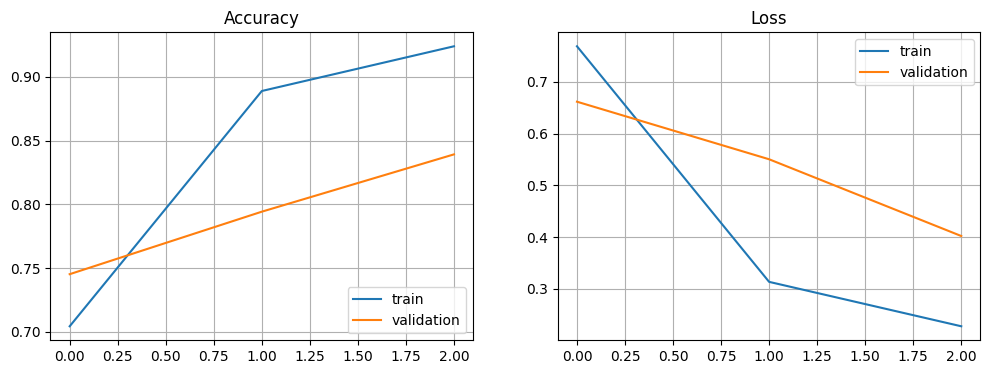

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - accuracy: 0.6945 - loss: 0.8047 - val_accuracy: 0.7452 - val_loss: 0.7602
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8794 - loss: 0.3277 - val_accuracy: 0.8025 - val_loss: 0.5497
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9121 - loss: 0.2376 - val_accuracy: 0.8297 - val_loss: 0.4938
Freeze first  20 layers: best val_accuracy = 0.8297
The highest training accuracy was 0.9121 in epoch 3
The final training accuracy was 0.9121
The highest validation accuracy was 0.8297 in epoch 3
The final validation accuracy was 0.8297
The lowest training loss was 0.2376 in epoch 3
The final training loss was 0.2376
The lowest validation loss was 0.4938 in epoch 3
The final validation loss was 0.4938


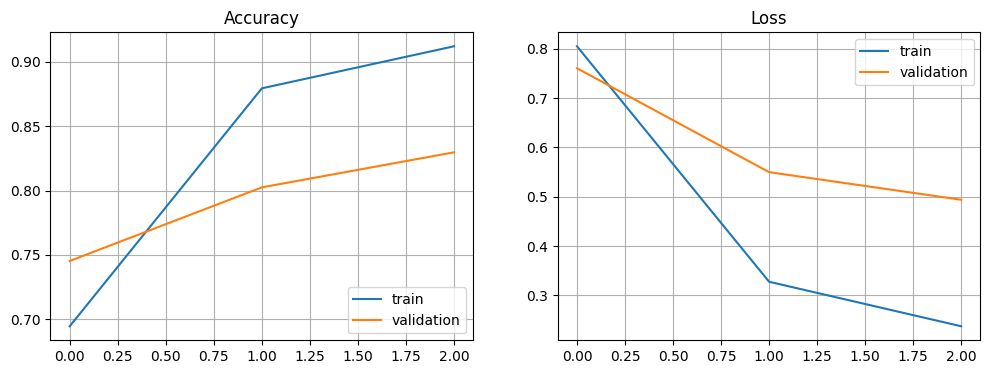

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.6901 - loss: 0.8156 - val_accuracy: 0.7302 - val_loss: 0.7358
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8804 - loss: 0.3332 - val_accuracy: 0.8106 - val_loss: 0.5329
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9234 - loss: 0.2234 - val_accuracy: 0.8406 - val_loss: 0.4312
Freeze first  40 layers: best val_accuracy = 0.8406
The highest training accuracy was 0.9234 in epoch 3
The final training accuracy was 0.9234
The highest validation accuracy was 0.8406 in epoch 3
The final validation accuracy was 0.8406
The lowest training loss was 0.2234 in epoch 3
The final training loss was 0.2234
The lowest validation loss was 0.4312 in epoch 3
The final validation loss was 0.4312


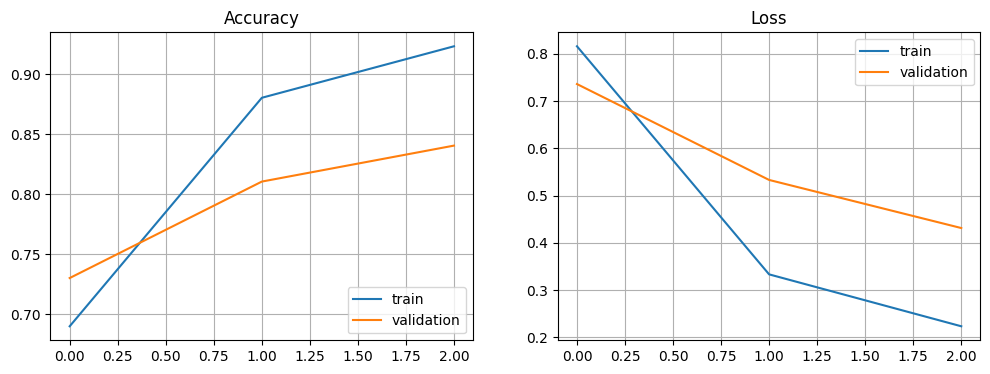

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.7016 - loss: 0.7948 - val_accuracy: 0.7834 - val_loss: 0.6536
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8879 - loss: 0.3100 - val_accuracy: 0.8202 - val_loss: 0.5171
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9227 - loss: 0.2186 - val_accuracy: 0.8515 - val_loss: 0.4200
Freeze first  60 layers: best val_accuracy = 0.8515
The highest training accuracy was 0.9227 in epoch 3
The final training accuracy was 0.9227
The highest validation accuracy was 0.8515 in epoch 3
The final validation accuracy was 0.8515
The lowest training loss was 0.2186 in epoch 3
The final training loss was 0.2186
The lowest validation loss was 0.4200 in epoch 3
The final validation loss was 0.4200


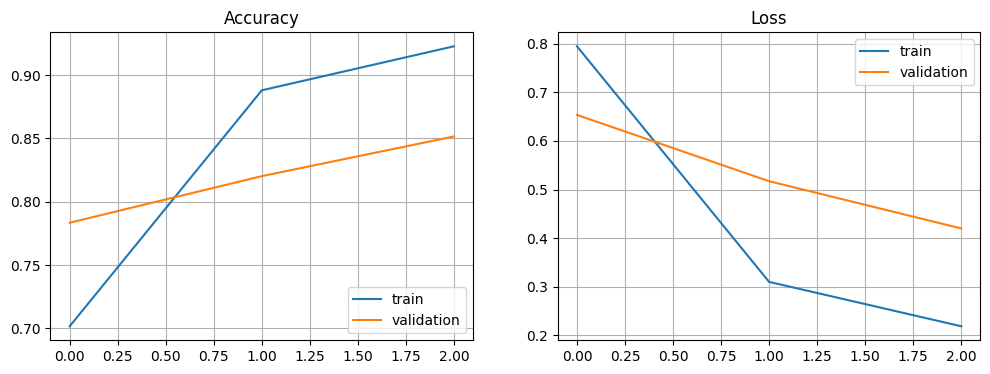

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.6921 - loss: 0.7946 - val_accuracy: 0.8120 - val_loss: 0.5429
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8893 - loss: 0.3204 - val_accuracy: 0.8624 - val_loss: 0.3899
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9230 - loss: 0.2221 - val_accuracy: 0.8869 - val_loss: 0.3097
Freeze first  80 layers: best val_accuracy = 0.8869
The highest training accuracy was 0.9230 in epoch 3
The final training accuracy was 0.9230
The highest validation accuracy was 0.8869 in epoch 3
The final validation accuracy was 0.8869
The lowest training loss was 0.2221 in epoch 3
The final training loss was 0.2221
The lowest validation loss was 0.3097 in epoch 3
The final validation loss was 0.3097


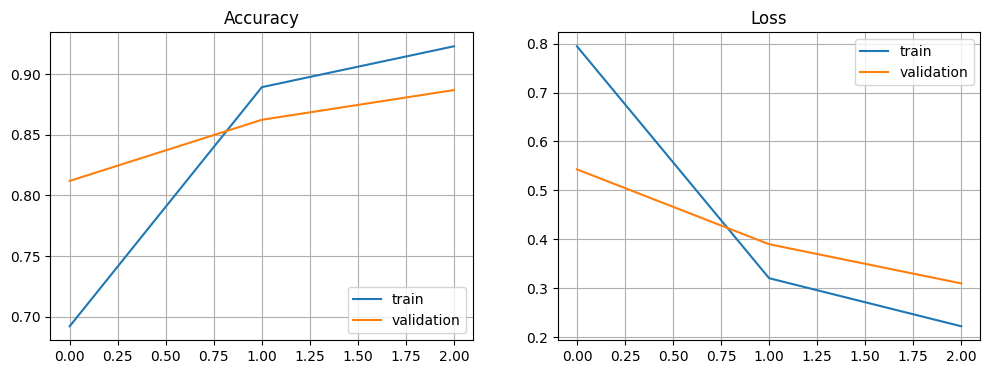

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step - accuracy: 0.7245 - loss: 0.7257 - val_accuracy: 0.7984 - val_loss: 0.5284
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8849 - loss: 0.3194 - val_accuracy: 0.8665 - val_loss: 0.3677
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9094 - loss: 0.2501 - val_accuracy: 0.8910 - val_loss: 0.3106
Freeze first 100 layers: best val_accuracy = 0.8910
The highest training accuracy was 0.9094 in epoch 3
The final training accuracy was 0.9094
The highest validation accuracy was 0.8910 in epoch 3
The final validation accuracy was 0.8910
The lowest training loss was 0.2501 in epoch 3
The final training loss was 0.2501
The lowest validation loss was 0.3106 in epoch 3
The final validation loss was 0.3106


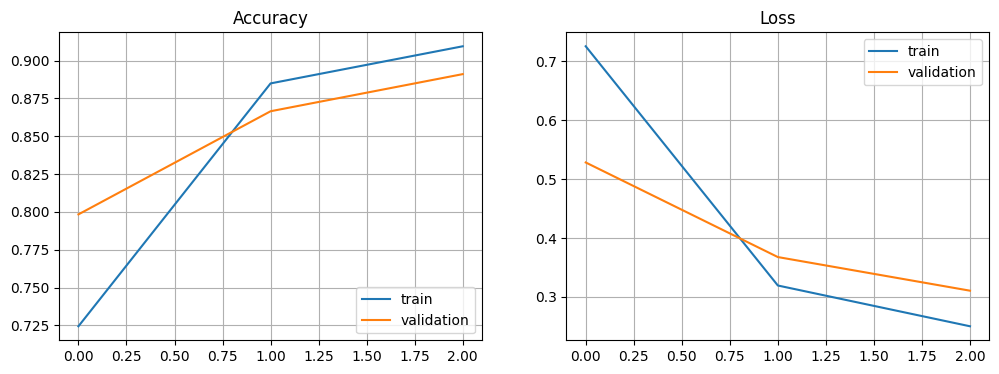

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.6979 - loss: 0.8057 - val_accuracy: 0.6839 - val_loss: 0.8798
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8791 - loss: 0.3385 - val_accuracy: 0.8025 - val_loss: 0.5231
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9097 - loss: 0.2571 - val_accuracy: 0.8174 - val_loss: 0.4869
Freeze first 120 layers: best val_accuracy = 0.8174
The highest training accuracy was 0.9097 in epoch 3
The final training accuracy was 0.9097
The highest validation accuracy was 0.8174 in epoch 3
The final validation accuracy was 0.8174
The lowest training loss was 0.2571 in epoch 3
The final training loss was 0.2571
The lowest validation loss was 0.4869 in epoch 3
The final validation loss was 0.4869


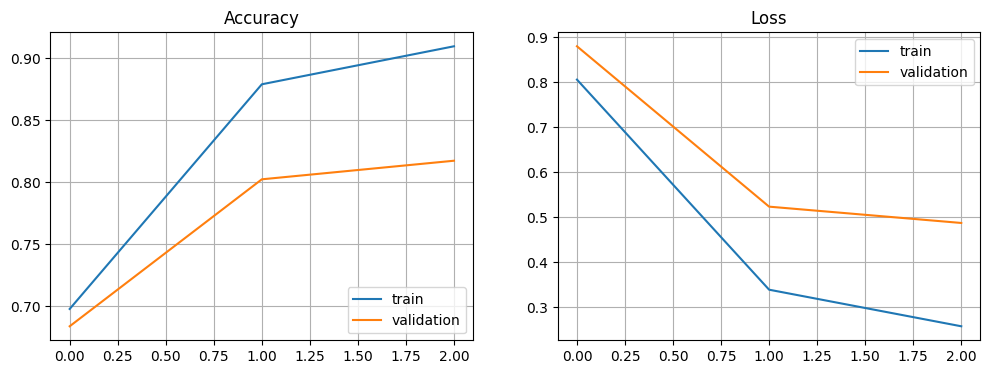

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.6982 - loss: 0.7984 - val_accuracy: 0.8351 - val_loss: 0.4621
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8689 - loss: 0.3612 - val_accuracy: 0.8842 - val_loss: 0.3262
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9019 - loss: 0.2774 - val_accuracy: 0.8747 - val_loss: 0.3335
Freeze first 140 layers: best val_accuracy = 0.8842
The highest training accuracy was 0.9019 in epoch 3
The final training accuracy was 0.9019
The highest validation accuracy was 0.8842 in epoch 2
The final validation accuracy was 0.8747
The lowest training loss was 0.2774 in epoch 3
The final training loss was 0.2774
The lowest validation loss was 0.3262 in epoch 2
The final validation loss was 0.3335


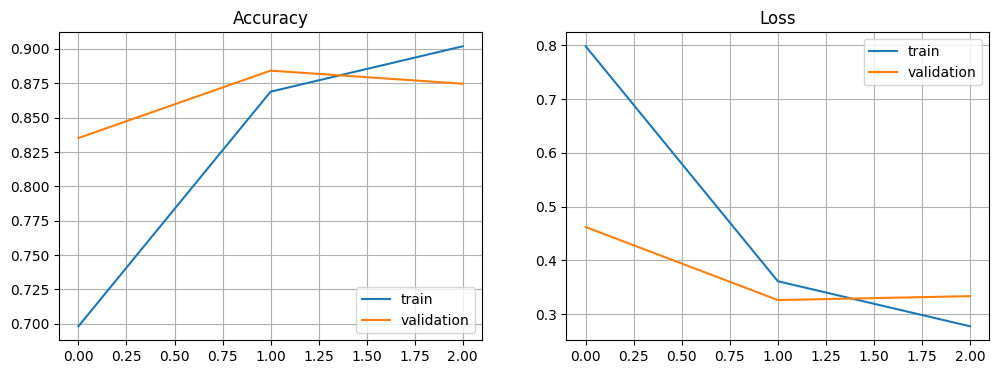

Epoch 1/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2204 - loss: 1.9390 - val_accuracy: 0.3529 - val_loss: 1.5948
Epoch 2/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3610 - loss: 1.5700 - val_accuracy: 0.4755 - val_loss: 1.3065
Epoch 3/3
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4728 - loss: 1.2929 - val_accuracy: 0.5640 - val_loss: 1.1090
Freeze first 154 layers: best val_accuracy = 0.5640
The highest training accuracy was 0.4728 in epoch 3
The final training accuracy was 0.4728
The highest validation accuracy was 0.5640 in epoch 3
The final validation accuracy was 0.5640
The lowest training loss was 1.2929 in epoch 3
The final training loss was 1.2929
The lowest validation loss was 1.1090 in epoch 3
The final validation loss was 1.1090


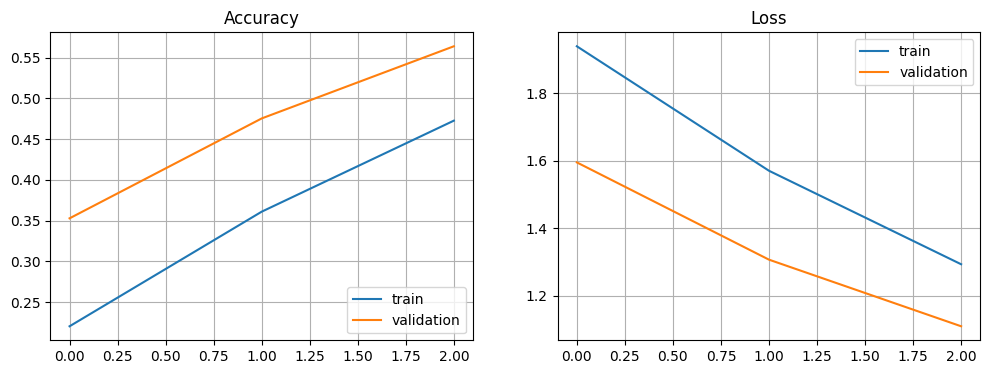

Best freeze point: 100 layers frozen; best validation accuracy = 0.8910


In [7]:
def build_and_train_model(start_fine_tune_at, epochs=3):
    tf.keras.backend.clear_session()

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights="imagenet",
    )

    base_model.trainable = True

    for layer in base_model.layers[:start_fine_tune_at]:
        layer.trainable = False

    inputs = Input(shape=IMG_SHAPE)

    x = data_augmentation(inputs)
    x = Rescaling(1.0 / 127.5, offset=-1)(x)

    x = base_model(
        x,
        training=False,
    )

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)

    outputs = Dense(
        len(class_names),
        activation="softmax",
    )(x)

    model = Model(
        inputs,
        outputs,
        name=f"mobilenetv2_freeze_{start_fine_tune_at}",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=1,
    )

    best_val_accuracy = max(
        history.history["val_accuracy"]
    )

    print(
        f"Freeze first {start_fine_tune_at:3d} layers: "
        f"best val_accuracy = {best_val_accuracy:.4f}"
    )

    return best_val_accuracy, history


freeze_points = list(
    range(0, total_layers, 20)
)

# Include the fully frozen backbone as an endpoint.
if total_layers not in freeze_points:
    freeze_points.append(total_layers)

val_accuracies = []
freeze_histories = {}

for freeze_at in freeze_points:
    val_acc, history = build_and_train_model(
        freeze_at,
        epochs=3,
    )

    val_accuracies.append(val_acc)
    freeze_histories[freeze_at] = history

    print_best_metrics(history.history)
    plot_results(history)

best_idx = int(
    np.argmax(val_accuracies)
)

best_freeze = freeze_points[best_idx]
best_acc = val_accuracies[best_idx]

print(
    f"Best freeze point: {best_freeze} layers frozen; "
    f"best validation accuracy = {best_acc:.4f}"
)


## Freeze-Depth Comparison

The validation results from the sweep can be plotted directly to visualize how much of the pretrained backbone should remain frozen.


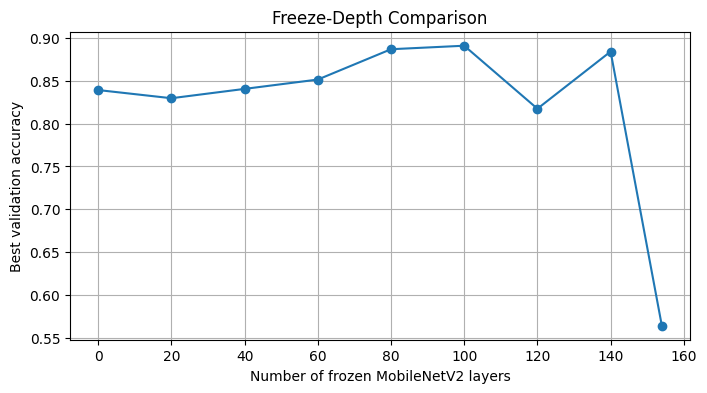

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(
    freeze_points,
    val_accuracies,
    marker="o",
)
plt.xlabel("Number of frozen MobileNetV2 layers")
plt.ylabel("Best validation accuracy")
plt.title("Freeze-Depth Comparison")
plt.grid(True)
plt.show()


## Experiment 2: Expand the Classification Head

The next model uses the selected freeze depth and adds batch normalization, two dense layers, and additional dropout above the pretrained feature extractor.


Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.4748 - loss: 1.3981 - val_accuracy: 0.7262 - val_loss: 0.7952
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7531 - loss: 0.6701 - val_accuracy: 0.7956 - val_loss: 0.5456
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8195 - loss: 0.4881 - val_accuracy: 0.8283 - val_loss: 0.4730
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8621 - loss: 0.3818 - val_accuracy: 0.8651 - val_loss: 0.3987
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8835 - loss: 0.3298 - val_accuracy: 0.8733 - val_loss: 0.3711
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9033 - loss: 0.2852 - val_accuracy: 0.8733 - val_loss: 0.3876
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9125 - loss: 0.2492 - val_accuracy: 0.8828 - val_loss: 0.3593
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9240 - loss: 0.2096 - val_accuracy: 0.8883 - 

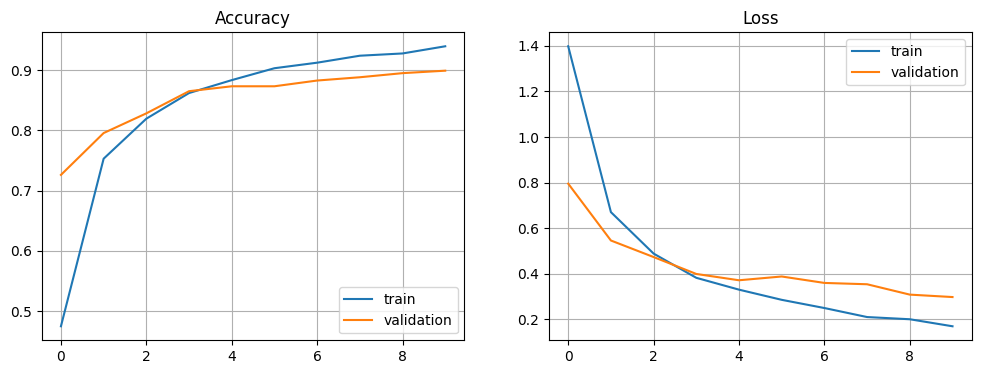

In [9]:
head_base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

head_base.trainable = True

for layer in head_base.layers[:best_freeze]:
    layer.trainable = False

inputs = Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = Rescaling(1.0 / 127.5, offset=-1)(x)
x = head_base(x, training=False)

x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(
    256,
    activation="relu",
)(x)

x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(
    128,
    activation="relu",
)(x)

x = Dropout(0.2)(x)

outputs = Dense(
    len(class_names),
    activation="softmax",
)(x)

head_model = Model(
    inputs,
    outputs,
    name="mobilenetv2_extended_classifier",
)

head_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_extended_head = head_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1,
)

print_best_metrics(history_extended_head.history)
plot_results(history_extended_head)


## Inspect the Target Labels

The flower task uses a single integer label for each image, so the model is a five-class **single-label** classifier.


In [10]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())


Image batch shape: (64, 160, 160, 3)
Label batch shape: (64,)
First 10 labels: [4 4 0 2 1 4 4 1 1 4]


## Experiment 3: Change the Classification-Layer Initialization

This experiment keeps the transfer-learning structure but explicitly changes the initialization of the final classification layer.


Model: "mobilenetv2_custom_initializer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,867,845 (7.13 MB)

 Non-trainable params: 396,544 (1.51 MB)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.7340 - loss: 0.8679 - val_accuracy: 0.8188 - val_loss: 0.5008
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8886 - loss: 0.3466 - val_accuracy: 0.8692 - val_loss: 0.3545
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9189 - loss: 0.2480 - val_accuracy: 0.8951 - val_loss: 0.2851
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9401 - loss: 0.1818 - val_accuracy: 0.9087 - val_loss: 0.2530
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9550 - loss: 0.1407 - val_accuracy: 0.9074 - val_loss: 0.2556
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9670 - loss: 0.1053 - val_accuracy: 0.9223 - val_loss: 0.2335
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9693 - loss: 0.0927 - val_accuracy: 0.9114 - val_loss: 0.2703
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9854 - loss: 0.0618 - val_accuracy: 0.8978 - 

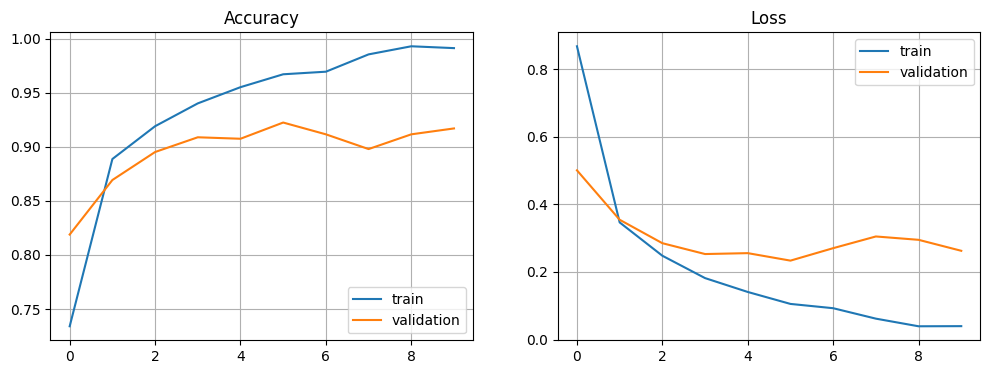

In [11]:
initializer_base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet",
)

initializer_base.trainable = True

for layer in initializer_base.layers[:best_freeze]:
    layer.trainable = False

inputs = Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = Rescaling(1.0 / 127.5, offset=-1)(x)
x = initializer_base(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)

outputs = Dense(
    len(class_names),
    activation="softmax",
    kernel_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.01,
    ),
    bias_initializer=tf.keras.initializers.Constant(
        value=0.0
    ),
)(x)

initializer_model = Model(
    inputs,
    outputs,
    name="mobilenetv2_custom_initializer",
)

initializer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

initializer_model.summary()

history_custom_initializer = initializer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1,
)

print_best_metrics(history_custom_initializer.history)
plot_results(history_custom_initializer)


### Custom-Initializer Interpretation

This experiment changes the initialization of the final classification layer while keeping the pretrained MobileNetV2 backbone. A smaller random-normal standard deviation and a lower learning rate are used to make optimization more stable. The goal is to evaluate whether the initialization choice materially changes convergence or validation performance relative to the other transfer-learning configurations.


## Experiment 4: Use a Different Pretrained Backbone

InceptionV3 replaces MobileNetV2 as the ImageNet feature extractor. Because the flower task has five mutually exclusive classes, the output layer uses **softmax** with sparse categorical crossentropy.


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "inceptionv3_flower_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 3, 3, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,813,029 (83.21 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 146ms/step - accuracy: 0.6625 - loss: 0.8709 - val_accuracy: 0.7888 - val_loss: 0.5615
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7871 - loss: 0.5708 - val_accuracy: 0.8256 - val_loss: 0.4973
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8110 - loss: 0.5216 - val_accuracy: 0.8270 - val_loss: 0.4860
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8215 - loss: 0.4816 - val_accuracy: 0.8188 - val_loss: 0.5102
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8283 - loss: 0.4657 - val_accuracy: 0.8460 - val_loss: 0.4632
Epoch 6/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8399 - loss: 0.4710 - val_accuracy: 0.8311 - val_loss: 0.4911
Epoch 7/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8386 - loss: 0.4649 - val_accuracy: 0.8447 - val_loss: 0.4683
Epoch 8/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8426 - loss: 0.4330 - val_accuracy: 0.8379 -

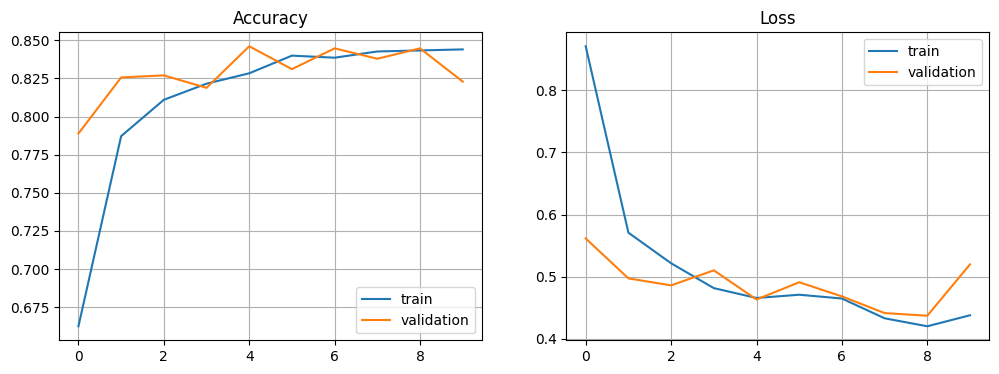

In [12]:
inception_base = tf.keras.applications.InceptionV3(
    input_shape=IMG_SHAPE,
    weights="imagenet",
    include_top=False,
)

# Use InceptionV3 as a frozen feature extractor.
inception_base.trainable = False

inputs = Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = Rescaling(1.0 / 127.5, offset=-1)(x)
x = inception_base(x, training=False)

x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)

outputs = Dense(
    len(class_names),
    activation="softmax",
    kernel_initializer=tf.keras.initializers.RandomNormal(
        mean=0.0,
        stddev=0.01,
    ),
    bias_initializer=tf.keras.initializers.Constant(
        value=0.0
    ),
)(x)

inception_model = Model(
    inputs,
    outputs,
    name="inceptionv3_flower_classifier",
)

inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

inception_model.summary()

history_inception = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1,
)

print_best_metrics(history_inception.history)
plot_results(history_inception)


## Results Interpretation

The experiments compare several transfer-learning decisions rather than assuming that one pretrained configuration is automatically best. The freeze-depth sweep shows that validation performance is sensitive to how much of MobileNetV2 is fine-tuned. The expanded classification head provides additional task-specific capacity and can improve adaptation to the five flower classes. The custom-initializer experiment isolates the effect of classifier initialization, while the InceptionV3 experiment shows that changing the pretrained backbone can produce a different accuracy/complexity tradeoff.

Among the evaluated Flower transfer-learning configurations, the corrected custom-initializer MobileNetV2 model achieved the highest validation accuracy of 92.23%. The expanded classification head reached 89.92%, while the best freeze-depth configuration, with the first 100 MobileNetV2 layers frozen, reached 89.10%. The frozen InceptionV3 model achieved 84.60%, showing that a larger pretrained backbone did not provide better performance for this task.


## Experiment Summary

The flower experiments examine four separate transfer-learning decisions:

1. **Freeze depth:** how much of MobileNetV2 should be updated.
2. **Classification-head capacity:** whether extra dense and normalization layers improve adaptation.
3. **Classifier initialization:** how a different initial distribution affects optimization.
4. **Backbone selection:** how MobileNetV2 compares conceptually with an alternative pretrained architecture such as InceptionV3.

These experiments demonstrate that transfer learning involves both architecture choices and optimization choices, not simply loading pretrained weights.
